# Übungsblatt 6 - Sprachproben auswerten

Dieses Notebook gehört zu **Übungsblatt 6**.

Ziel:
1. `samples.csv` laden.
2. Sprachproben anzeigen.
3. Metadaten einfach ergänzen.
4. Signalverlauf plotten.
5. Wortgrenzen grob erkennen.
6. Signal-Rausch-Verhältnis einfach berechnen.

Die Datei `samples.csv` muss vorher mit **Thonny** vom ESP32 auf den PC heruntergeladen werden.

## 1. Bibliotheken importieren

Hier werden nur einfache Bibliotheken benutzt.

In [9]:
import pandas as pd              # Für Tabellen und CSV-Dateien
import matplotlib.pyplot as plt  # Für Diagramme
import numpy as np               # Für einfache Berechnungen

## 2. CSV-Datei laden

Die Datei `samples.csv` enthält pro Zeile eine Aufnahme.

Format:

`NameDerAufnahme, sample1, sample2, sample3, ...`

In [10]:
filename = "samples.csv"

# CSV ohne feste Spaltennamen laden
data = pd.read_csv(filename, header=None)

# erste Zeilen anzeigen
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,Hallo_01,32768,34000,35500,37000,38500,37000,35500,34000,32768,31500,30000,28500,27000,28500,30000,31500,32768
1,Hallo_02,32768,33000,34000,35000,36000,35000,34000,33000,32768,32500,32000,31500,31000,31500,32000,32500,32768
2,Test_01,32768,35000,38000,40000,42000,40000,38000,35000,32768,30000,27000,25000,23000,25000,27000,30000,32768
3,Test_02,32768,33500,34500,36000,37500,36000,34500,33500,32768,32000,31000,30000,29000,30000,31000,32000,32768
4,Sprache_01,32768,34500,36500,39000,41000,39000,36500,34500,32768,31000,29000,27000,25000,27000,29000,31000,32768


## 3. Übersicht über die Aufnahmen

Hier sieht man, wie viele Aufnahmen geladen wurden.

In [11]:
# Anzahl der Aufnahmen bestimmen
anzahl_aufnahmen = len(data)

# Ausgabe
print("Anzahl der Aufnahmen:", anzahl_aufnahmen)

# Namen der Aufnahmen anzeigen
print("Aufnahmen:")
print(data.iloc[:, 0])

Anzahl der Aufnahmen: 5
Aufnahmen:
0      Hallo_01
1      Hallo_02
2       Test_01
3       Test_02
4    Sprache_01
Name: 0, dtype: str


## 4. Metadaten-Tabelle erstellen

Die Metadaten wurden laut Aufgabe zusätzlich notiert.

Diese Tabelle kann man manuell anpassen.

In [12]:
# einfache Metadaten-Tabelle vorbereiten
metadata = pd.DataFrame({
    "aufnahme": data.iloc[:, 0],          # Name aus der CSV-Datei
    "satz": [""] * len(data),             # gesprochener Satz
    "sprecher": [""] * len(data),         # Name oder Kürzel
    "sprache": [""] * len(data),          # z.B. Deutsch, Englisch, Persisch
    "geschlecht": [""] * len(data),       # optional
    "alter": [""] * len(data),            # optional
    "sample_rate": [4000] * len(data)     # Sample-Rate aus ue6.py
})

# Metadaten anzeigen
metadata

,aufnahme,satz,sprecher,sprache,geschlecht,alter,sample_rate
0,Hallo_01,,,,,,4000
1,Hallo_02,,,,,,4000
2,Test_01,,,,,,4000
3,Test_02,,,,,,4000
4,Sprache_01,,,,,,4000


## 5. Eine Aufnahme auswählen

Hier wird eine Aufnahme ausgewählt und als Zahlenreihe vorbereitet.

Die erste Spalte ist der Name. Danach kommen die Samples.

In [13]:
aufnahme_index = 0                # hier kann man 0, 1, 2, ... auswählen

# Name der Aufnahme lesen
aufnahme_name = data.iloc[aufnahme_index, 0]

# Samples ab Spalte 1 lesen
samples = data.iloc[aufnahme_index, 1:].dropna().astype(float).to_numpy()

# einfache Ausgabe
print("Aufnahme:", aufnahme_name)
print("Anzahl Samples:", len(samples))
print("Min:", samples.min())
print("Max:", samples.max())

Aufnahme: Hallo_01
Anzahl Samples: 17
Min: 27000.0
Max: 38500.0


## 6. Signalverlauf plotten

Hier sieht man den Verlauf der Sprachprobe über die Zeit.

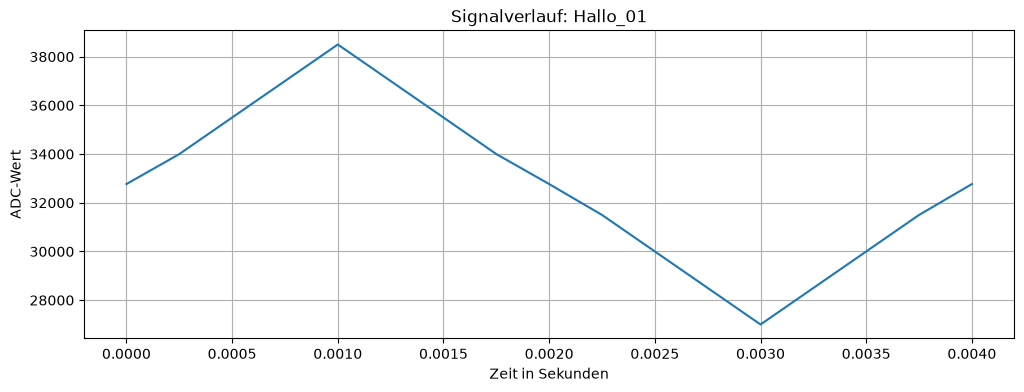

In [14]:
fs = 4000                         # Abtastfrequenz in Hz

# Zeitachse berechnen
zeit = np.arange(len(samples)) / fs

# Signal plotten
plt.figure(figsize=(12, 4))
plt.plot(zeit, samples)
plt.title("Signalverlauf: " + str(aufnahme_name))
plt.xlabel("Zeit in Sekunden")
plt.ylabel("ADC-Wert")
plt.grid(True)
plt.show()

## 7. Alle Aufnahmen kurz plotten

Damit kann man schnell prüfen, ob alle Aufnahmen sinnvoll gespeichert wurden.

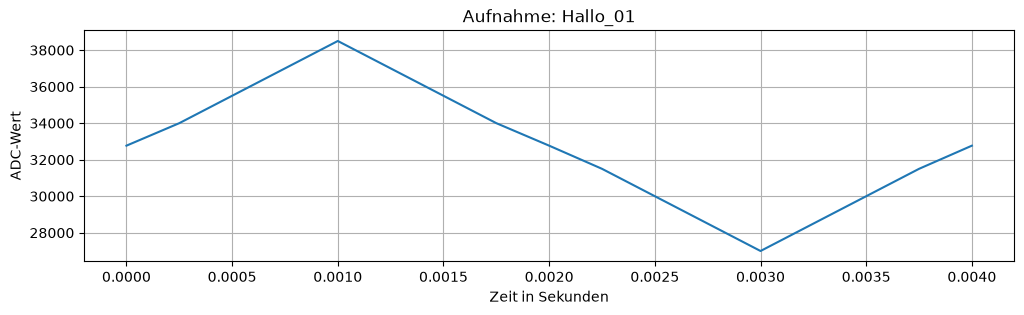

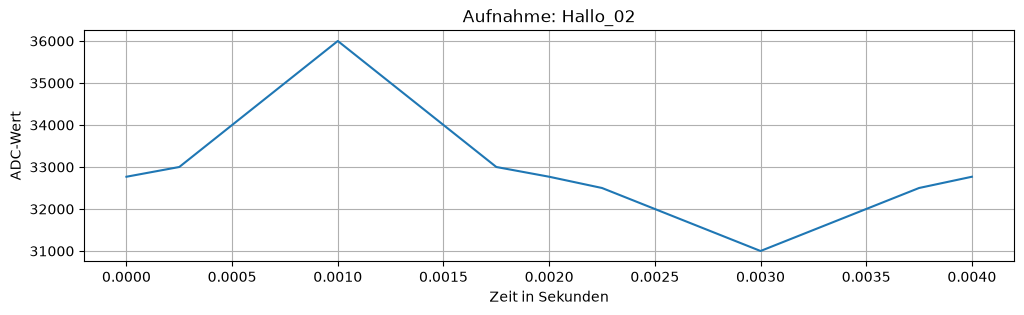

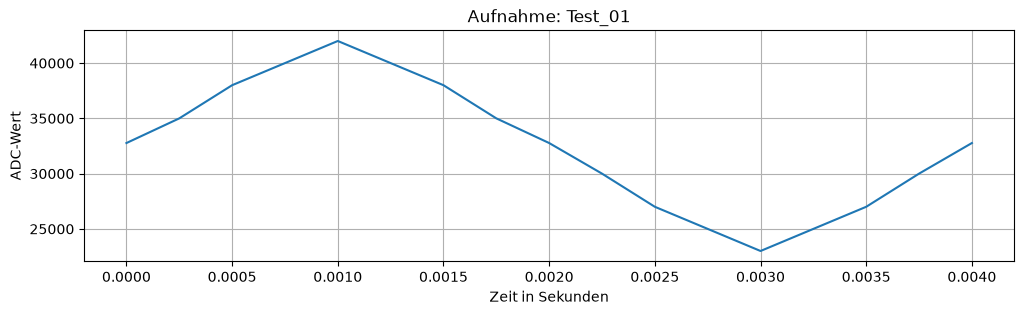

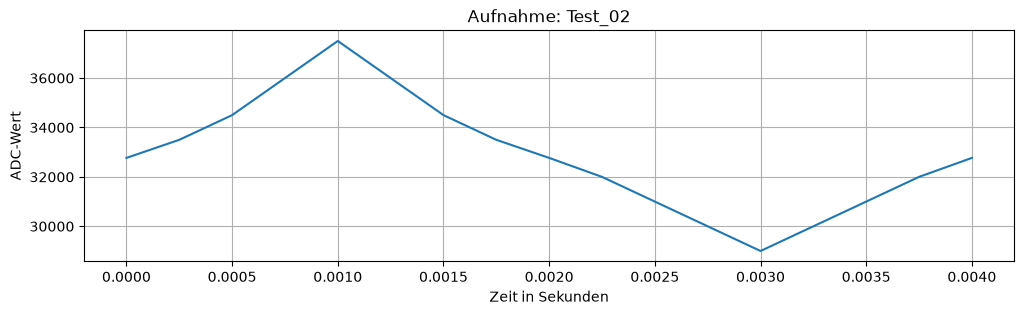

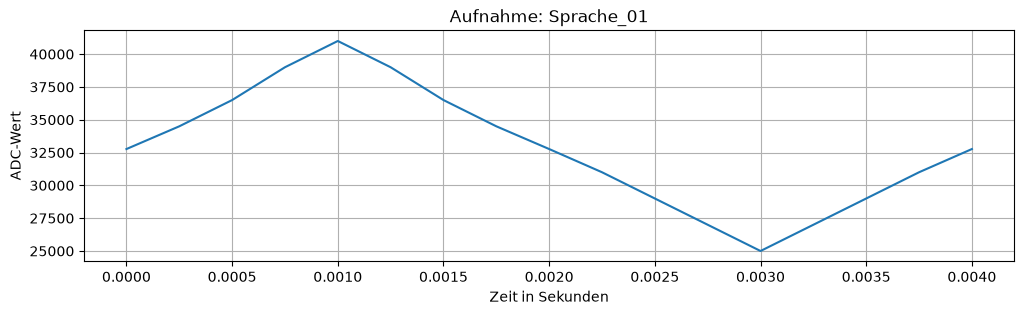

In [15]:
for i in range(len(data)):
    # Name der Aufnahme
    name = data.iloc[i, 0]
    
    # Samples der Aufnahme
    s = data.iloc[i, 1:].dropna().astype(float).to_numpy()
    
    # Zeitachse
    t = np.arange(len(s)) / fs
    
    # Plot
    plt.figure(figsize=(12, 3))
    plt.plot(t, s)
    plt.title("Aufnahme: " + str(name))
    plt.xlabel("Zeit in Sekunden")
    plt.ylabel("ADC-Wert")
    plt.grid(True)
    plt.show()

## 8. Wortgrenzen grob erkennen

Idee:

- Sprache hat meistens größere Ausschläge.
- Stille oder Rauschen hat kleinere Ausschläge.
- Mit einem einfachen Schwellwert kann man grob sehen, wo gesprochen wurde.

Das ist keine perfekte Methode, aber für die Übung ausreichend.

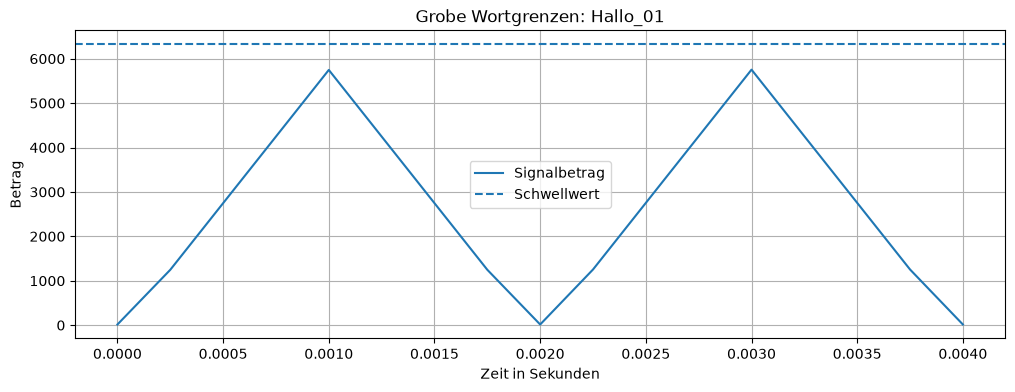

In [16]:
# Mittelwert entfernen, damit das Signal um 0 liegt
signal = samples - np.mean(samples)

# Betrag des Signals berechnen
betrag = np.abs(signal)

# einfacher Schwellwert
schwellwert = np.mean(betrag) + 2 * np.std(betrag)

# Stellen finden, wo wahrscheinlich Sprache ist
sprache = betrag > schwellwert

# Plot mit Schwellwert
plt.figure(figsize=(12, 4))
plt.plot(zeit, betrag, label="Signalbetrag")
plt.axhline(schwellwert, linestyle="--", label="Schwellwert")
plt.title("Grobe Wortgrenzen: " + str(aufnahme_name))
plt.xlabel("Zeit in Sekunden")
plt.ylabel("Betrag")
plt.legend()
plt.grid(True)
plt.show()

## 9. Signal und erkannte Sprachbereiche anzeigen

Hier werden die erkannten Sprachbereiche markiert.

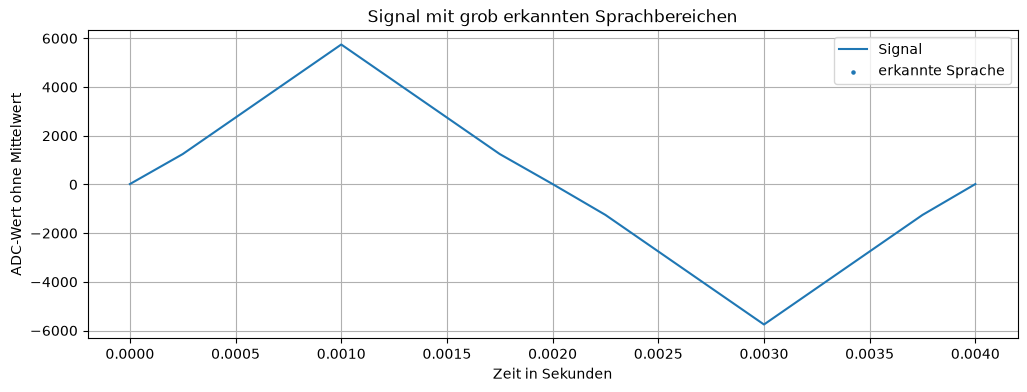

In [17]:
plt.figure(figsize=(12, 4))
plt.plot(zeit, signal, label="Signal")
plt.scatter(zeit[sprache], signal[sprache], s=5, label="erkannte Sprache")
plt.title("Signal mit grob erkannten Sprachbereichen")
plt.xlabel("Zeit in Sekunden")
plt.ylabel("ADC-Wert ohne Mittelwert")
plt.legend()
plt.grid(True)
plt.show()

## 10. Einfaches Signal-Rausch-Verhältnis berechnen

Sehr einfache Idee:

- **Signalbereich:** Werte über dem Schwellwert.
- **Rauschbereich:** Werte unter dem Schwellwert.

Dann wird das Verhältnis in dB berechnet.

In [18]:
# Signalwerte und Rauschwerte trennen
signal_werte = signal[sprache]
rausch_werte = signal[~sprache]

# mittlere Leistung berechnen
signal_leistung = np.mean(signal_werte ** 2)
rausch_leistung = np.mean(rausch_werte ** 2)

# SNR berechnen
snr = 10 * np.log10(signal_leistung / rausch_leistung)

# Ergebnis ausgeben
print("Signal-Leistung:", signal_leistung)
print("Rausch-Leistung:", rausch_leistung)
print("SNR:", snr, "dB")

Signal-Leistung: nan
Rausch-Leistung: 10286811.792387541
SNR: nan dB


c:\Users\reza2\Desktop\WorkDesk\GitHub\Uni\esp32-audio-sampler\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\reza2\Desktop\WorkDesk\GitHub\Uni\esp32-audio-sampler\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## 11. Kurze Auswertung

Hier kann man die Ergebnisse kurz beschreiben.

In [19]:
print("Auswertung:")
print("Die Sprachbereiche erkennt man an den größeren Ausschlägen im Signal.")
print("Leise Bereiche oder Pausen haben kleinere Ausschläge und zählen hier als Rauschen.")
print("Das berechnete SNR zeigt grob, wie stark die Sprache im Vergleich zum Rauschen ist.")

Auswertung:
Die Sprachbereiche erkennt man an den größeren Ausschlägen im Signal.
Leise Bereiche oder Pausen haben kleinere Ausschläge und zählen hier als Rauschen.
Das berechnete SNR zeigt grob, wie stark die Sprache im Vergleich zum Rauschen ist.
